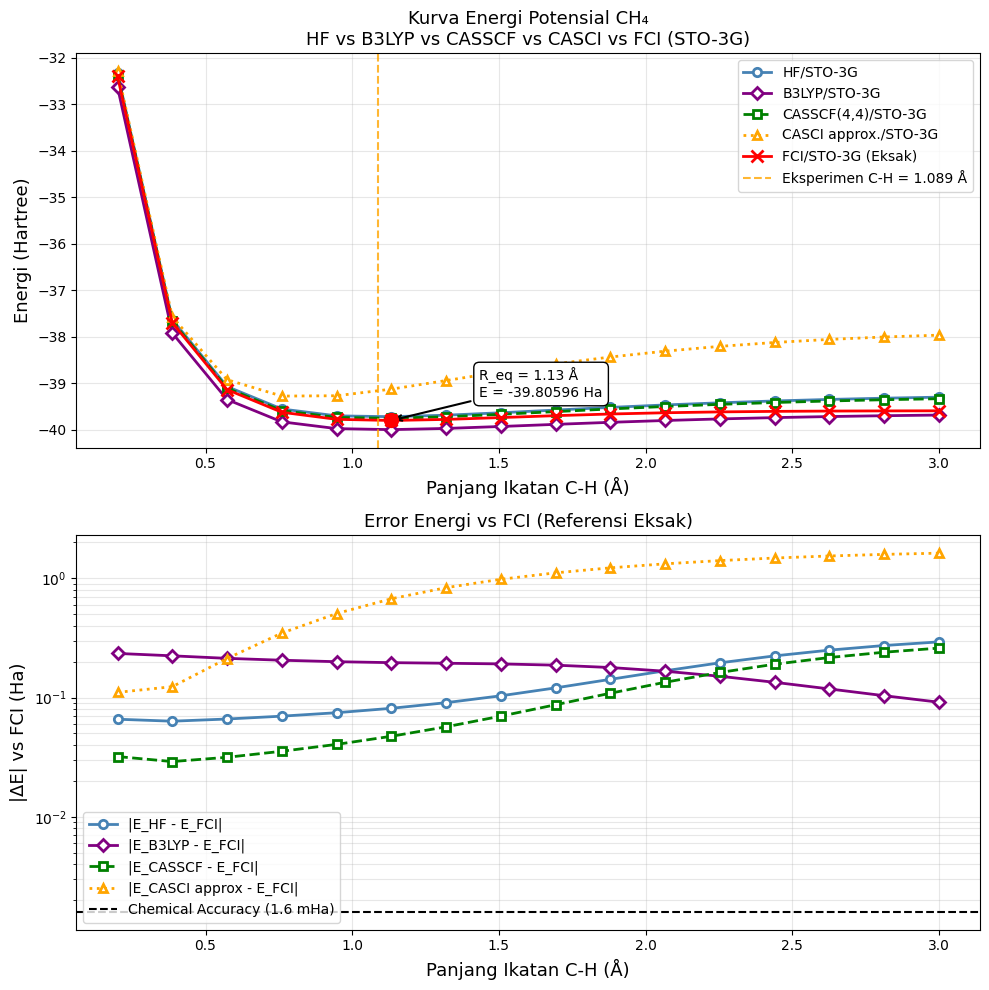

FCI    → R_eq = 1.13 Å | E = -39.805956 Ha
CASSCF → R_eq = 1.13 Å | E = -39.758588 Ha


In [1]:
import matplotlib.pyplot as plt
import numpy as np

jarak = np.linspace(0.20, 3.00, 16)

energi_hf = [
    -32.336000191432,
    -37.637718563705,
    -39.075699255955,
    -39.559102825242,
    -39.706069007281,
    -39.724638933953,
    -39.692124129941,
    -39.639740325812,
    -39.581576309361,
    -39.524442585321,
    -39.471859815672,
    -39.425571306592,
    -39.386104923316,
    -39.353203233385,
    -39.326226496231,
    -39.304410028251
]

energi_dft = [
    -32.636543420727,
    -37.925204411020,
    -39.355217844531,
    -39.834803490010,
    -39.980781254853,
    -40.002344852725,
    -39.976924356474,
    -39.934950506294,
    -39.889277135995,
    -39.845486328389,
    -39.806141272322,
    -39.772349733564,
    -39.744276321928,
    -39.721506020290,
    -39.703371390558,
    -39.689176852059
]

energi_casscf = [
    -32.369842898406,
    -37.672043985844,
    -39.110249153749,
    -39.593508704174,
    -39.740235829317,
    -39.758588133079,
    -39.725902504558,
    -39.673385575863,
    -39.615114565420,
    -39.557893225850,
    -39.505238331845,
    -39.458890436056,
    -39.419375157900,
    -39.386433272367,
    -39.359423000487,
    -39.337578606815
]

energi_casci = [
    -32.291244005265,
    -37.577651277213,
    -38.929047582951,
    -39.281206563700,
    -39.273875260650,
    -39.131666061612,
    -38.946893765853,
    -38.760357168645,
    -38.589614897443,
    -38.440889024157,
    -38.315321697415,
    -38.211841403356,
    -38.128295691107,
    -38.062030697432,
    -38.010290817485,
    -37.970459651493
]

energi_fci = [
    -32.401861780719,
    -37.701116924142,
    -39.141819912423,
    -39.628982870568,
    -39.780746783152,
    -39.805956153980,
    -39.782784351585,
    -39.743279018281,
    -39.702220751700,
    -39.666708996177,
    -39.639702827530,
    -39.621326528198,
    -39.609919741206,
    -39.603301815513,
    -39.599639696623,
    -39.597685663160
]

# Referensi = FCI
e_ref        = np.array(energi_fci)
error_hf     = np.abs(np.array(energi_hf)     - e_ref)
error_dft    = np.abs(np.array(energi_dft)    - e_ref)
error_casscf = np.abs(np.array(energi_casscf) - e_ref)
error_casci  = np.abs(np.array(energi_casci)  - e_ref)

CA = 0.0016

idx_fci    = energi_fci.index(min(energi_fci))
idx_casscf = energi_casscf.index(min(energi_casscf))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ── Plot 1: PES ──
ax1.plot(jarak, energi_hf,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(jarak, energi_dft,    'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(jarak, energi_casscf, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(4,4)/STO-3G')
ax1.plot(jarak, energi_casci,  '^:',  color='orange',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx./STO-3G')
ax1.plot(jarak, energi_fci,    'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI/STO-3G (Eksak)')

ax1.plot(jarak[idx_fci], energi_fci[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq = {jarak[idx_fci]:.2f} Å\nE = {energi_fci[idx_fci]:.5f} Ha',
             xy=(jarak[idx_fci], energi_fci[idx_fci]),
             xytext=(jarak[idx_fci]+0.3, energi_fci[idx_fci]+0.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=1.089, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen C-H = 1.089 Å')
ax1.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial CH₄\nHF vs B3LYP vs CASSCF vs CASCI vs FCI (STO-3G)',
              fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error vs FCI ──
ax2.semilogy(jarak, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(jarak, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(jarak, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(jarak, error_casci  + 1e-10, '^:',  color='orange',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA, color='black', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=13)
ax2.set_ylabel('|ΔE| vs FCI (Ha)', fontsize=13)
ax2.set_title('Error Energi vs FCI (Referensi Eksak)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('PES_CH4_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"FCI    → R_eq = {jarak[idx_fci]:.2f} Å | E = {energi_fci[idx_fci]:.6f} Ha")
print(f"CASSCF → R_eq = {jarak[idx_casscf]:.2f} Å | E = {energi_casscf[idx_casscf]:.6f} Ha")

In [2]:
# ═══════════════════════════════════════════════════════════
# RINGKASAN ENERGI ELEKTRONIK - CH4 (STO-3G)
# ═══════════════════════════════════════════════════════════
print("="*65)
print("RINGKASAN ENERGI ELEKTRONIK MOLEKUL CH₄ (STO-3G)")
print("="*65)
print(f"{'Metode':<20} {'E_min (Ha)':>15} {'R_eq (Å)':>12} {'ΔE vs FCI (Ha)':>16}")
print("-"*65)

metode_ch4 = {
    'HF':              energi_hf,
    'B3LYP':           energi_dft,
    'CASSCF(4,4)':     energi_casscf,
    'CASCI approx.':   energi_casci,
}

e_fci_min = min(energi_fci)
idx_fci   = energi_fci.index(e_fci_min)

for nama, data in metode_ch4.items():
    idx   = data.index(min(data))
    e_min = data[idx]
    r_eq  = jarak[idx]
    delta = abs(e_min - e_fci_min)
    print(f"{nama:<20} {e_min:>15.6f} {r_eq:>12.2f} {delta:>16.6e}")

print("-"*65)
print(f"{'FCI (eksak)':<20} {e_fci_min:>15.6f} {jarak[idx_fci]:>12.2f} {'referensi':>16}")
print("="*65)

RINGKASAN ENERGI ELEKTRONIK MOLEKUL CH₄ (STO-3G)
Metode                    E_min (Ha)     R_eq (Å)   ΔE vs FCI (Ha)
-----------------------------------------------------------------
HF                        -39.724639         1.13     8.131722e-02
B3LYP                     -40.002345         1.13     1.963887e-01
CASSCF(4,4)               -39.758588         1.13     4.736802e-02
CASCI approx.             -39.281207         0.76     5.247496e-01
-----------------------------------------------------------------
FCI (eksak)               -39.805956         1.13        referensi
